# How many things is this actually measuring?

*Question, Intuition, Math, Code, Assumptions, How it breaks*

The project rests on a sentence: **a player must clear a floor on every
requirement**. Independent hurdles, each one a different demand, and only 6% of
players clear all of them.

That sentence has a load-bearing word in it, and it is not the count. It is
"independent", which nobody had checked. Checking it cost the project one of its
requirements.

## 1. Question

Twelve requirements go into the gate. How many separate things do they actually
test?

## 2. Intuition

Here is the arithmetic that should have bothered me from the beginning.

Each requirement rejects the bottom 40% of players. If they were independent,
the share clearing all twelve would be $0.6^{12}$, which is **0.22%**, or about
twelve players out of five and a half thousand. The real figure is several
times higher, and the code below states exactly how many.

That gap is not a mistake. It is correlation, and it is what you would expect:
good players tend to be good at several things at once. But it means the gate is
nothing like twelve hurdles. It is a smaller number of hurdles wearing twelve
labels, and until you know how many, "must have all of them" is a claim about
the label count rather than about football.

There is a second thing worth finding out. If two requirements measure the same
underlying quality, the composite counts that quality twice, and a player strong
in it is rewarded twice for one virtue.

## 3. Math

Three measurements, from weakest to most useful.

**The correlation matrix** $C$, on the standardised career profile the gate
actually sees. One entry per pair.

**Eigenvalues.** $C$ has as many as there are requirements and they sum to that
number. If the requirements were independent every eigenvalue would be 1.
Concentration in the first few means the variation lives in fewer dimensions
than there are columns. The **participation ratio** turns that into one number:

$$k_{\text{eff}} = \frac{\left(\sum_i \lambda_i\right)^2}{\sum_i \lambda_i^2}$$

**Equivalent independent requirements.** The most directly interpretable of the
three. If the observed pass rate is $p$ and each floor passes 60%, then the gate
behaves like $k$ independent floors where $0.6^k = p$:

$$k = \frac{\ln p}{\ln 0.6}$$

That last one answers the question in the units the claim was made in.

## 4. Code

### The matrix

In [1]:
import numpy as np
import pandas as pd

from gambeta import needs

ranking = pd.read_parquet("../data/sample/ranking.parquet")
keys = [r.key for r in needs.OUTFIELD]
labels = {r.key: r.label for r in needs.OUTFIELD}

C = ranking[keys].corr()
C.rename(index=labels, columns=labels).style.format("{:.2f}").background_gradient(
    cmap="RdBu_r", vmin=-1, vmax=1, axis=None
)

,Scores goals,Creates goals,Finishes clinically,Generates threat,Carries his team,Is available,Sees matches out,Sustains it,Has no bad seasons,Does not cost his team,Delivers in Europe,Shows up for his country
Scores goals,1.00,0.57,0.57,0.94,0.92,-0.15,0.10,0.07,0.81,-0.12,0.47,0.34
Creates goals,0.57,1.00,0.30,0.67,0.52,-0.11,-0.01,0.12,0.62,-0.06,0.46,0.31
Finishes clinically,0.57,0.30,1.00,0.47,0.57,-0.07,0.15,0.08,0.52,-0.19,0.23,0.19
Generates threat,0.94,0.67,0.47,1.00,0.90,-0.17,0.08,0.05,0.79,-0.15,0.45,0.33
Carries his team,0.92,0.52,0.57,0.90,1.00,0.00,0.22,0.06,0.79,-0.12,0.32,0.26
Is available,-0.15,-0.11,-0.07,-0.17,0.00,1.00,0.54,0.28,0.24,0.30,0.06,0.08
Sees matches out,0.10,-0.01,0.15,0.08,0.22,0.54,1.00,0.20,0.36,-0.03,0.13,0.14
Sustains it,0.07,0.12,0.08,0.05,0.06,0.28,0.20,1.00,0.13,0.06,0.23,0.13
Has no bad seasons,0.81,0.62,0.52,0.79,0.79,0.24,0.36,0.13,1.00,0.16,0.57,0.45
Does not cost his team,-0.12,-0.06,-0.19,-0.15,-0.12,0.30,-0.03,0.06,0.16,1.00,0.06,0.06


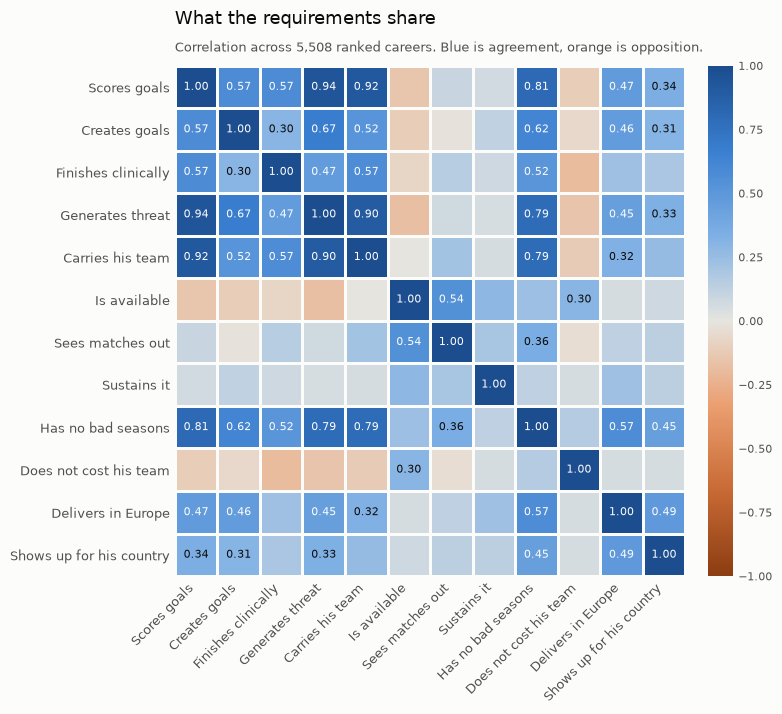

In [2]:
import pandas as pd

from gambeta import needs, tifo

ranking = pd.read_parquet("../data/sample/ranking.parquet")
keys = [r.key for r in needs.OUTFIELD]
labels = {r.key: r.label for r in needs.OUTFIELD}

C = ranking[keys].corr()

fig = tifo.matrix(
    C.rename(index=labels, columns=labels),
    title="What the requirements share",
    subtitle="Correlation across 5,508 ranked careers. Blue is agreement, orange is opposition.",
    diverging=True,
    label_if=0.30,
)

Blue blocks are requirements that rise together. The scale is centred on zero,
so a pale cell means two requirements genuinely have little to say about each
other, and only correlations past 0.30 are printed, because a grid where every
cell carries a number is a table wearing a costume.

Read the top-left block first. `scoring`, `threat`, `team_share` and
`consistency` sit between 0.79 and 0.94 with each other. That is not four
separate requirements, it is one attacking quality measured four ways.

Then the pair that used to sit much closer together: `availability` and
`reliability` are now at **0.54**, down from the 0.7 an earlier version of
this chapter reported. Being on the pitch and being picked to start are
related but no longer nearly the same fact about a player, since `reliability`
was redefined to measure completed matches against a player's position rather
than a coarser share.

In [3]:
# Upper triangle only, so each pair is named once.
upper = C.where(~np.tril(np.ones(C.shape, dtype=bool)))
pairs = (
    upper.melt(ignore_index=False, var_name="other", value_name="r")
    .dropna()
    .set_index("other", append=True)["r"]
    .sort_values(key=abs, ascending=False)
)
print("the six strongest relationships between supposedly separate requirements:\n")
for (a, b), v in pairs.head(6).items():
    print(f"  {labels[a]:<24} {labels[b]:<24} {v:+.4f}")

the six strongest relationships between supposedly separate requirements:

  Scores goals             Generates threat         +0.9439
  Scores goals             Carries his team         +0.9188
  Generates threat         Carries his team         +0.9023
  Scores goals             Has no bad seasons       +0.8106
  Carries his team         Has no bad seasons       +0.7930
  Generates threat         Has no bad seasons       +0.7919


**The largest of those used to be 0.9999, and it is why this chapter exists.**

There was an eleventh requirement, `above_team`, meant to separate a player from
the side around him: score 20 for a title winner and it should count for less
than 20 for a relegation side. It was built as the residual of scoring after
regressing on the club's ClubElo rating.

It correlated **0.9999** with `scoring`, and the smallest eigenvalue of the
matrix was zero, which is linear algebra saying one column is a copy of another.

Two things were wrong. The ClubElo adapter had been filtering to England since
Phase 1, so four leagues in five had no rating at all and were quietly given the
average. And once that was fixed, club strength turned out to explain **0.8%** of
who scores inside a league-season. The residual of something barely explained is
the thing back again.

No rebuild rescued it. Every other requirement was measured against club
strength and the best was `creation` at 1.1%. Attacking output is individual.

So the definition lost a requirement and went from eleven to ten. The
composite had been counting one quality twice, and removing it moved the answer:
Mbappé left the top five, Kane and Henry moved up.

`continental` and `tournament` arrived after that, measuring Champions League
and international-tournament output rather than restating club strength, and
they brought the outfield list back to twelve. The matrix and the eigenvalues
below are computed on that current twelve, not the ten this chapter's diagnosis
originally left behind.

**It survives on the goalkeeper list**, where the same construction explains
**45%** of goals conceded. A keeper's goals-against is mostly his defence, and
the residual is the part that is his. Fixing the England-only bug turned that
board over: Cañizares now leads it.

### How many hurdles is the gate really?

In [4]:
eigenvalues = np.linalg.eigvalsh(C.to_numpy())[::-1]
observed = ranking["qualified"].mean()
n = len(keys)

print(f"eigenvalues (they sum to {n}; all ones would mean independence):")
print("  " + "  ".join(f"{v:.2f}" for v in eigenvalues))
print()
print(f"participation ratio          {eigenvalues.sum() ** 2 / (eigenvalues**2).sum():.2f}")
print(f"components for 90% variance  {int(np.searchsorted(np.cumsum(eigenvalues) / n, 0.90) + 1)}")
print()
print(f"pass rate if independent     {0.6**n:.4%}")
print(f"pass rate observed           {observed:.4%}")
print(f"equivalent independent gates {np.log(observed) / np.log(0.6):.2f}")

eigenvalues (they sum to 12; all ones would mean independence):
  4.97  1.94  1.21  0.98  0.81  0.65  0.50  0.44  0.34  0.08  0.05  0.04

participation ratio          4.43
components for 90% variance  7

pass rate if independent     0.2177%
pass rate observed           6.4815%
equivalent independent gates 5.36


**Twelve requirements behave like about five and a half.**

The three measures disagree with each other, and the disagreement is honest
rather than a problem. The participation ratio weights the largest eigenvalue
heavily and gives 4.43. Ninety per cent of the variance needs 7 components.
The pass-rate calculation gives 5.36. They ask slightly different questions,
and all three land between four and seven, which is the answer: **the gate
still tests roughly half as many things as it says it does**, now with
`continental` and `tournament` folded into the count as well as everything
that was there before.

### Does correlation actually explain the gap?

The claim above is that correlation, and nothing else, accounts for six and a
half per cent rather than 0.22%. That is testable. Draw fake players with
exactly this correlation structure and gate them the same way.

In [5]:
rng = np.random.default_rng(20260810)
draws = rng.multivariate_normal(np.zeros(len(keys)), C.to_numpy(), size=200_000)

floors = np.percentile(draws, 40, axis=0)
simulated = (draws >= floors).all(axis=1).mean()

n = len(keys)
print(f"independent requirements     {0.6**n:.4%}")
print(f"simulated, this correlation  {simulated:.4%}")
print(f"observed in the real data    {observed:.4%}")

independent requirements     0.2177%
simulated, this correlation  4.5260%
observed in the real data    6.4815%


Close, though not as tight as the earlier version of this chapter found.
The correlation structure alone gets the simulation to 4.53%, most of the way
from 0.22% to the observed 6.48%, so correlation is still doing most of the
work. The remainder is the same reason the fit was never exact: the
simulation assumes joint normality and the real requirements are skewed.

## 5. Assumptions

1. **Correlation captures the dependence.** Pearson sees linear relationships.
   Two requirements could be strongly dependent in a curved way and show a
   correlation near zero.
2. **The career profile is the right place to measure.** These are pooled,
   standardised career values, which is what the gate sees. The season-level
   picture is similar but not identical.
3. **The simulation's normality is wrong and useful anyway.** It is there to show
   that correlation explains most of the pass rate, not to model the
   distribution faithfully.

## 6. How it breaks

**Effective dimensionality is not a verdict on any single requirement.**

It would be easy to read "five and a half" as "delete five requirements", and
that does not follow. A requirement can be highly correlated with others and
still be the one doing the eliminating at the margin. Chapter 3 checks that
directly for `discipline`, and the honest finding there is that every
season-level requirement now ties for the most eliminations under the
percentile gate, `discipline` included, not that any one of them stands
alone. Correlation describes the population; the gate acts on individuals.

The one case where the reading was safe was a correlation of 0.9999, because there
is no margin left for a duplicate to act differently at.

**What this chapter changed.**

It settled that `above_team` was not a separate requirement, and the outfield
list dropped to ten because of it, before `continental` and `tournament`
brought it back to twelve. That was a fact rather than a judgement, which
is why acting on it did not need an argument.

It also hands the open question about `reliability` a piece of evidence worth
revisiting. The sensitivity chapter found that `reliability` is the
requirement that gives way first whenever any threshold is tightened. This
chapter now finds it correlates only 0.54 with `availability`, well down from
the 0.7 it carried under the coarser definition. A requirement that is fragile
under tightening is no longer also the most redundant one, which weakens the
case for cutting it rather than strengthening it.